In [196]:
from pathlib import Path
import os
from typing import Any, Iterator, List, Optional, Tuple, Union

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

try:
    from numpy.exceptions import AxisError
except ImportError:
    from numpy import AxisError  # type: ignore

import batdetect2.detector.compute_features as feats
import batdetect2.detector.post_process as pp
import batdetect2.utils.audio_utils as au
from batdetect2.detector import parameters
from batdetect2.detector.parameters import DEFAULT_MODEL_PATH
from batdetect2.types import (
    Annotation,
    DetectionModel,
    FileAnnotations,
    ModelOutput,
    ModelParameters,
    PredictionResults,
    ProcessingConfiguration,
    ResultParams,
    RunResults,
    SpectrogramParameters,
)

In [15]:
import batdetect2.api as api

In [16]:
import soundfile as sf
import pandas as pd

In [198]:
segment_example = f'/home/adkris/bat-detector-msds/daily_notebooks/20250101__group_threshold_sweep_results/20220730_053000__0.00_30.00.wav'

In [199]:
api_results = api.process_file(segment_example)

In [200]:
api_detections = pd.DataFrame(api_results['pred_dict']['annotation'])
api_detections

,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event
0,0.0015,0.0096,18593,26317,Plecotus austriacus,0.005,0.020,-1,Echolocation
1,0.0015,0.0331,68437,80505,Rhinolophus ferrumequinum,0.022,0.022,-1,Echolocation
2,0.0015,0.0106,26328,37117,Eptesicus serotinus,0.009,0.027,-1,Echolocation
3,0.0285,0.0686,68437,82840,Rhinolophus ferrumequinum,0.032,0.032,-1,Echolocation
4,0.1255,0.1639,68437,82127,Rhinolophus ferrumequinum,0.021,0.021,-1,Echolocation
...,...,...,...,...,...,...,...,...,...
1329,29.9655,30.0050,68437,82707,Rhinolophus ferrumequinum,0.027,0.027,-1,Echolocation
1330,30.0075,30.0197,47812,55052,Pipistrellus pipistrellus,0.021,0.027,-1,Echolocation
1331,30.0075,30.0157,37500,45994,Pipistrellus nathusii,0.011,0.021,-1,Echolocation
1332,30.0085,30.0192,25468,37940,Eptesicus serotinus,0.022,0.048,-1,Echolocation


## How are there 5 detections outside of the 30-sec file segment?

In [20]:
import batdetect2.utils.detector_utils as du

In [21]:
model = api.MODEL

In [22]:
device = api.DEVICE

In [23]:
config = api.CONFIG
config

{'detection_threshold': 0.01,
 'spec_slices': False,
 'chunk_size': 3,
 'spec_features': False,
 'cnn_features': False,
 'quiet': True,
 'target_samp_rate': 256000,
 'fft_win_length': 0.002,
 'fft_overlap': 0.75,
 'resize_factor': 0.5,
 'spec_divide_factor': 32,
 'spec_height': 256,
 'scale_raw_audio': False,
 'class_names': ['Barbastellus barbastellus',
  'Eptesicus serotinus',
  'Myotis alcathoe',
  'Myotis bechsteinii',
  'Myotis brandtii',
  'Myotis daubentonii',
  'Myotis mystacinus',
  'Myotis nattereri',
  'Nyctalus leisleri',
  'Nyctalus noctula',
  'Pipistrellus nathusii',
  'Pipistrellus pipistrellus',
  'Pipistrellus pygmaeus',
  'Plecotus auritus',
  'Plecotus austriacus',
  'Rhinolophus ferrumequinum',
  'Rhinolophus hipposideros'],
 'time_expansion': 1,
 'top_n': 3,
 'return_raw_preds': False,
 'max_duration': None,
 'nms_kernel_size': 9,
 'max_freq': 120000,
 'min_freq': 10000,
 'nms_top_k_per_sec': 200,
 'spec_scale': 'pcen',
 'denoise_spec_avg': True,
 'max_scale_spec'

In [24]:
du_results = du.process_file(
        segment_example,
        model,
        config,
        device,
    )

In [28]:
du_detections = pd.DataFrame(du_results['pred_dict']['annotation'])
du_detections

,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event
0,0.0015,0.0096,18593,26317,Plecotus austriacus,0.005,0.020,-1,Echolocation
1,0.0015,0.0331,68437,80505,Rhinolophus ferrumequinum,0.022,0.022,-1,Echolocation
2,0.0015,0.0106,26328,37117,Eptesicus serotinus,0.009,0.027,-1,Echolocation
3,0.0285,0.0686,68437,82840,Rhinolophus ferrumequinum,0.032,0.032,-1,Echolocation
4,0.1255,0.1639,68437,82127,Rhinolophus ferrumequinum,0.021,0.021,-1,Echolocation
...,...,...,...,...,...,...,...,...,...
1329,29.9655,30.0050,68437,82707,Rhinolophus ferrumequinum,0.027,0.027,-1,Echolocation
1330,30.0075,30.0197,47812,55052,Pipistrellus pipistrellus,0.021,0.027,-1,Echolocation
1331,30.0075,30.0157,37500,45994,Pipistrellus nathusii,0.011,0.021,-1,Echolocation
1332,30.0085,30.0192,25468,37940,Eptesicus serotinus,0.022,0.048,-1,Echolocation


## They are still there so let's copy the `process_file` code from detector_utils and generate model outputs for just the 3-sec chunk that batdetect2 uses

In [57]:
def process_file(
                    audio_file: str,
                    model: DetectionModel,
                    config: ProcessingConfiguration,
                    device: torch.device,
                ):
    """Process a single audio file with detection model.

    Will split the audio file into chunks if it is too long and
    process each chunk separately.

    Parameters
    ----------
    audio_file : str
        Path to audio file.

    model : torch.nn.Module
        Detection model.

    config : ProcessingConfiguration
        Configuration for processing.

    Returns
    -------
    results : Results or Any
        Results of processing audio file with the given detection model.
        Will be a dictionary if `config["return_raw_preds"]` is `True`,
    """
    # store temporary results here
    predictions = []
    spec_feats = []
    cnn_feats = []
    spec_slices = []

    # Get original sampling rate
    file_samp_rate = librosa.get_samplerate(audio_file)
    orig_samp_rate = file_samp_rate * (config.get("time_expansion") or 1)

    # load audio file
    sampling_rate, audio_full = au.load_audio(
        audio_file,
        time_exp_fact=config.get("time_expansion", 1) or 1,
        target_samp_rate=config["target_samp_rate"],
        scale=config["scale_raw_audio"],
        max_duration=config.get("max_duration"),
    )

    # loop through larger file and split into chunks
    # TODO: fix so that it overlaps correctly and takes care of
    # duplicate detections at borders
    for chunk_time, audio in du.iterate_over_chunks(
        audio_full,
        sampling_rate,
        config["chunk_size"],
    ):
        # Run detection model on chunk
        pred_nms, features, spec = du._process_audio_array(
            audio,
            sampling_rate,
            model,
            config,
            device,
        )

        # convert to numpy
        spec_np = spec.detach().cpu().numpy().squeeze()

        # add chunk time to start and end times
        pred_nms["start_times"] += chunk_time
        pred_nms["end_times"] += chunk_time

        predictions.append(pred_nms)

        # extract features - if there are any calls detected
        if pred_nms["det_probs"].shape[0] == 0:
            continue

        if config["spec_features"]:
            spec_feats.append(feats.get_feats(spec_np, pred_nms, config))

        if config["cnn_features"]:
            cnn_feats.append(features[0])

        if config["spec_slices"]:
            # FIX: This is not currently working. Returns empty slices
            spec_slices.extend(feats.extract_spec_slices(spec_np, pred_nms))

    # Merge results from chunks
    predictions, spec_feats, cnn_feats, spec_slices = du._merge_results(
        predictions,
        spec_feats,
        cnn_feats,
        spec_slices,
    )

    # convert results to a dictionary in the right format
    results = du.convert_results(
        file_id=os.path.basename(audio_file),
        time_exp=config.get("time_expansion", 1) or 1,
        duration=audio_full.shape[0] / float(sampling_rate),
        params=config,
        predictions=predictions,
        spec_feats=spec_feats,
        cnn_feats=cnn_feats,
        spec_slices=spec_slices,
        nyquist_freq=orig_samp_rate / 2,
    )

    # summarize results
    if not config["quiet"]:
        du.summarize_results(results, predictions, config)

    if config["return_raw_preds"]:
        return predictions

    return results

## Set up just like batdetect2 does but only pick the last 3-sec chunk where the >30 start_time detections are

In [58]:
# store temporary results here
predictions = []
spec_feats = []
cnn_feats = []
spec_slices = []

# Get original sampling rate
file_samp_rate = librosa.get_samplerate(segment_example)
orig_samp_rate = file_samp_rate * (config.get("time_expansion") or 1)

# load audio file
sampling_rate, audio_full = au.load_audio(
    segment_example,
    time_exp_fact=config.get("time_expansion", 1) or 1,
    target_samp_rate=config["target_samp_rate"],
    scale=config["scale_raw_audio"],
    max_duration=config.get("max_duration"),
)

In [59]:
last_chunk = list(du.iterate_over_chunks(
    audio_full,
    sampling_rate,
    config["chunk_size"],
))[-1]

In [137]:
# loop through larger file and split into chunks
chunk_time = last_chunk[0]
audio = last_chunk[-1]
# Run detection model on chunk
pred_nms, features, spec = du._process_audio_array(
    audio,
    sampling_rate,
    model,
    config,
    device,
)

# convert to numpy
spec_np = spec.detach().cpu().numpy().squeeze()

# add chunk time to start and end times
pred_nms["start_times"] += chunk_time
pred_nms["end_times"] += chunk_time

In [61]:
pred_nms.keys()

dict_keys(['det_probs', 'x_pos', 'y_pos', 'bb_width', 'bb_height', 'start_times', 'end_times', 'low_freqs', 'high_freqs', 'class_probs'])

In [62]:
raw_dets = pd.DataFrame()
for key in ['start_times', 'end_times', 'low_freqs', 'high_freqs', 'det_probs']:
    raw_dets[key] = pred_nms[key]
raw_dets

,start_times,end_times,low_freqs,high_freqs,det_probs
0,27.001499,27.031399,68437.500,79392.117188,0.038293
1,27.001499,27.010717,24609.375,31202.898438,0.028227
2,27.018499,27.051283,93359.375,111994.546875,0.025422
3,27.023500,27.056665,93359.375,111555.125000,0.026502
4,27.032499,27.062860,93359.375,111411.875000,0.024111
...,...,...,...,...,...
296,29.972500,30.005274,93359.375,111162.859375,0.042796
297,30.007500,30.019709,47812.500,55052.027344,0.027174
298,30.007500,30.015673,37500.000,45994.929688,0.021423
299,30.008499,30.019182,25468.750,37940.007812,0.048050


## And of course, when we convert results, these out-of-scope detections are still there.

`convert_results` removes overlapping detections but maybe batdetect2 people don't know about this

In [63]:
predictions = [pred_nms]

In [46]:
# Merge results from chunks
predictions, spec_feats, cnn_feats, spec_slices = du._merge_results(
    predictions,
    spec_feats,
    cnn_feats,
    spec_slices,
)

# convert results to a dictionary in the right format
results = du.convert_results(
    file_id=os.path.basename(segment_example),
    time_exp=config.get("time_expansion", 1) or 1,
    duration=audio_full.shape[0] / float(sampling_rate),
    params=config,
    predictions=predictions,
    spec_feats=spec_feats,
    cnn_feats=cnn_feats,
    spec_slices=spec_slices,
    nyquist_freq=orig_samp_rate / 2,
)

In [48]:
pd.DataFrame(results['pred_dict']['annotation'])

,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event
0,27.0015,27.0314,68437,79392,Rhinolophus ferrumequinum,0.038,0.038,-1,Echolocation
1,27.0015,27.0107,24609,31202,Nyctalus leisleri,0.011,0.028,-1,Echolocation
2,27.0475,27.0557,32343,41509,Myotis daubentonii,0.008,0.024,-1,Echolocation
3,27.0775,27.1157,68437,81751,Rhinolophus ferrumequinum,0.023,0.023,-1,Echolocation
4,27.1055,27.1416,68437,81673,Rhinolophus ferrumequinum,0.021,0.021,-1,Echolocation
...,...,...,...,...,...,...,...,...,...
165,29.9655,30.0050,68437,82707,Rhinolophus ferrumequinum,0.027,0.027,-1,Echolocation
166,30.0075,30.0197,47812,55052,Pipistrellus pipistrellus,0.021,0.027,-1,Echolocation
167,30.0075,30.0157,37500,45994,Pipistrellus nathusii,0.011,0.021,-1,Echolocation
168,30.0085,30.0192,25468,37940,Eptesicus serotinus,0.022,0.048,-1,Echolocation


We need to dive into `_process_audio_array()` perhaps. But also remember that `convert_results()` is also used to get rid of similarly frequency-related out-of-scope detections which are higher frequency because detections are generated for a 256kHz file

In [64]:
def _process_audio_array(
    audio: np.ndarray,
    sampling_rate: int,
    model: DetectionModel,
    config: ProcessingConfiguration,
    device: torch.device,
) -> Tuple[PredictionResults, np.ndarray, torch.Tensor]:
    # load audio file and compute spectrogram
    _, spec, _ = du.compute_spectrogram(
        audio,
        sampling_rate,
        {
            "fft_win_length": config["fft_win_length"],
            "fft_overlap": config["fft_overlap"],
            "spec_height": config["spec_height"],
            "resize_factor": config["resize_factor"],
            "spec_divide_factor": config["spec_divide_factor"],
            "max_freq": config["max_freq"],
            "min_freq": config["min_freq"],
            "spec_scale": config["spec_scale"],
            "denoise_spec_avg": config["denoise_spec_avg"],
            "max_scale_spec": config["max_scale_spec"],
        },
        device,
        return_np=False,
    )

    # process spectrogram with model
    pred_nms, features = du._process_spectrogram(
        spec,
        sampling_rate,
        model,
        config,
    )

    return pred_nms, features, spec

In [88]:
def compute_spectrogram(
    audio: np.ndarray,
    sampling_rate: int,
    params: SpectrogramParameters,
    device: torch.device,
    return_np: bool = False,
) -> Tuple[float, torch.Tensor, Optional[np.ndarray]]:
    """Compute a spectrogram from an audio array.

    Will pad the audio array so that it is evenly divisible by the
    downsampling factors.

    Parameters
    ----------
    audio : np.ndarray

    sampling_rate : int

    params : SpectrogramParameters
        The parameters to use for generating the spectrogram.

    return_np : bool, optional
        Whether to return the spectrogram as a numpy array as well as a
        torch tensor. The default is False.

    Returns
    -------
    duration : float
        The duration of the spectrgram in seconds.

    spec : torch.Tensor
        The spectrogram as a torch tensor.

    spec_np : np.ndarray, optional
        The spectrogram as a numpy array. Only returned if `return_np` is
        True, otherwise None.
    """
    # pad audio so it is evenly divisible by downsampling factors
    duration = audio.shape[0] / float(sampling_rate)
    audio = au.pad_audio(
        audio,
        sampling_rate,
        params["fft_win_length"],
        params["fft_overlap"],
        params["resize_factor"],
        params["spec_divide_factor"],
    )

    # generate spectrogram
    spec, _ = au.generate_spectrogram(audio, sampling_rate, params)

    # convert to pytorch
    spec = torch.from_numpy(spec).to(device)

    # add batch and channel dimensions
    spec = spec.unsqueeze(0).unsqueeze(0)

    # resize the spec
    resize_factor = params["resize_factor"]
    spec_op_shape = (
        int(params["spec_height"] * resize_factor),
        int(spec.shape[-1] * resize_factor),
    )
    spec = F.interpolate(
        spec,
        size=spec_op_shape,
        mode="bilinear",
        align_corners=False,
    )

    if return_np:
        spec_np = spec[0, 0, :].cpu().data.numpy()
    else:
        spec_np = None

    return duration, spec, spec_np

In [128]:
params = {
            "fft_win_length": config["fft_win_length"],
            "fft_overlap": config["fft_overlap"],
            "spec_height": config["spec_height"],
            "resize_factor": config["resize_factor"],
            "spec_divide_factor": config["spec_divide_factor"],
            "max_freq": config["max_freq"],
            "min_freq": config["min_freq"],
            "spec_scale": config["spec_scale"],
            "denoise_spec_avg": config["denoise_spec_avg"],
            "max_scale_spec": config["max_scale_spec"],
        }

# pad audio so it is evenly divisible by downsampling factors
duration = audio.shape[0] / float(sampling_rate)
audio_padded = au.pad_audio(
    audio,
    sampling_rate,
    params["fft_win_length"],
    params["fft_overlap"],
    params["resize_factor"],
    params["spec_divide_factor"],
)

print(f'Length of padded audio: {audio_padded.shape[0]/sampling_rate}')

Length of padded audio: 3.0095


## Below I'm just showing initially there is nothing after 3.0s

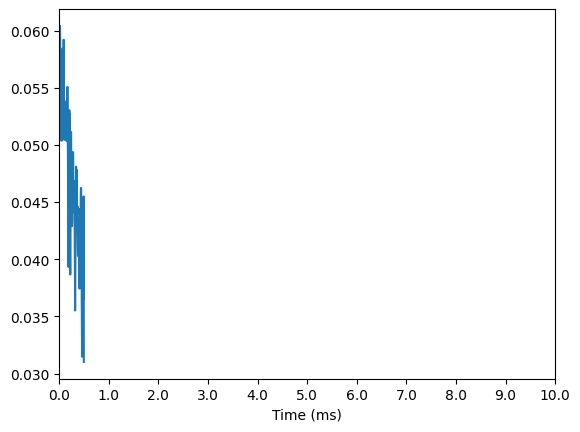

In [136]:
plot_start = 2.9995
plt.plot(audio[int(plot_start*sampling_rate):])
plt.xticks(np.linspace(0, audio_padded.shape[0] - (plot_start*sampling_rate), 11),
           np.round(1000*np.linspace(0, audio_padded.shape[0]/sampling_rate - plot_start, 11)))
plt.xlabel('Time (ms)')
plt.xlim(0, audio_padded.shape[0] - (plot_start*sampling_rate))
plt.show()

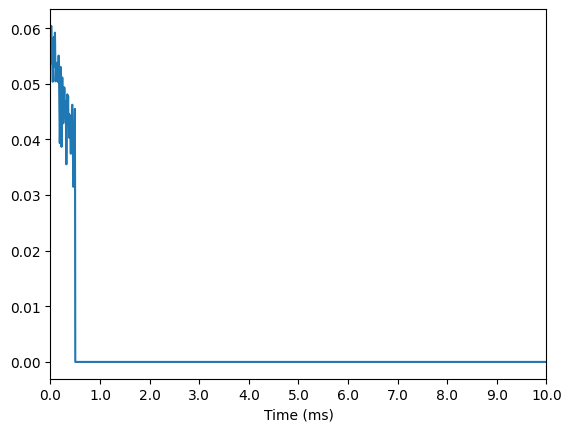

In [135]:
plot_start = 2.9995
plt.plot(audio_padded[int(plot_start*sampling_rate):])
plt.xticks(np.linspace(0, audio_padded.shape[0] - (plot_start*sampling_rate), 11),
           np.round(1000*np.linspace(0, audio_padded.shape[0]/sampling_rate - plot_start, 11)))
plt.xlabel('Time (ms)')
plt.xlim(0, audio_padded.shape[0] - (plot_start*sampling_rate))
plt.show()

## This must be why the detections are beyond the expected 3-sec chunk.

In [111]:
params

{'fft_win_length': 0.002,
 'fft_overlap': 0.75,
 'spec_height': 256,
 'resize_factor': 0.5,
 'spec_divide_factor': 32,
 'max_freq': 120000,
 'min_freq': 10000,
 'spec_scale': 'pcen',
 'denoise_spec_avg': True,
 'max_scale_spec': False}

## And indeed, they say the audio segment is passed with zeros but batdetect2 still detects calls with very low detectin probability

In [112]:
def pad_audio(
    audio: np.ndarray,
    samplerate: int = parameters.TARGET_SAMPLERATE_HZ,
    window_duration: float = parameters.FFT_WIN_LENGTH_S,
    window_overlap: float = parameters.FFT_OVERLAP,
    resize_factor: float = parameters.RESIZE_FACTOR,
    divide_factor: int = parameters.SPEC_DIVIDE_FACTOR,
    fixed_width: Optional[int] = None,
):
    """Pad audio to be evenly divisible by `divide_factor`.

    This function pads the audio signal with zeros to ensure that the
    generated spectrogram length will be evenly divisible by `divide_factor`.
    This is important for the model to work correctly.

    This `divide_factor` comes from the model architecture as it downscales
    the spectrogram by this factor, so the input must be divisible by this
    integer number.

    Parameters
    ----------
    audio : np.ndarray
        The audio signal.
    samplerate : int
        The sampling rate of the audio signal.
    window_size : float
        The window size in seconds used for the spectrogram computation.
    window_overlap : float
        The overlap between windows in the spectrogram computation.
    resize_factor : float
        This factor is used to resize the spectrogram after the STFT
        computation. Default is 0.5 which means that the spectrogram will be
        reduced by half. Important to take into account for the final size of
        the spectrogram.
    divide_factor : int
        The factor by which the spectrogram will be divided.
    fixed_width : int, optional
        If provided, the audio will be padded or cut so that the resulting
        spectrogram width will be equal to this value.

    Returns
    -------
    np.ndarray
        The padded audio signal.
    """
    spec_width = au.compute_spectrogram_width(
        audio.shape[0],
        samplerate=samplerate,
        window_duration=window_duration,
        window_overlap=window_overlap,
        resize_factor=resize_factor,
    )

    if fixed_width:
        target_samples = au.x_coord_to_sample(
            fixed_width,
            samplerate=samplerate,
            window_duration=window_duration,
            window_overlap=window_overlap,
            resize_factor=resize_factor,
        )

        if spec_width < fixed_width:
            # need to be at least min_size
            diff = target_samples - audio.shape[0]
            return np.hstack((audio, np.zeros(diff, dtype=audio.dtype)))

        if spec_width > fixed_width:
            return audio[:target_samples]

        return audio

    min_width = int(divide_factor / resize_factor)

    if spec_width < min_width:
        target_samples = au.x_coord_to_sample(
            min_width,
            samplerate=samplerate,
            window_duration=window_duration,
            window_overlap=window_overlap,
            resize_factor=resize_factor,
        )
        diff = target_samples - audio.shape[0]
        return np.hstack((audio, np.zeros(diff, dtype=audio.dtype)))

    if (spec_width % divide_factor) == 0:
        return audio

    target_width = int(np.ceil(spec_width / divide_factor)) * divide_factor
    target_samples = au.x_coord_to_sample(
        target_width,
        samplerate=samplerate,
        window_duration=window_duration,
        window_overlap=window_overlap,
        resize_factor=resize_factor,
    )
    diff = target_samples - audio.shape[0]
    return np.hstack((audio, np.zeros(diff, dtype=audio.dtype)))

## This means every 3-second chunk will have detections like this! (not just the 30-sec segment ones)

In [142]:
# loop through larger file and split into chunks
chunk_time = last_chunk[0]
audio = last_chunk[-1]
# Run detection model on chunk
pred_nms, features, spec = du._process_audio_array(
    audio,
    sampling_rate,
    model,
    config,
    device,
)

raw_dets = pd.DataFrame()
for key in ['start_times', 'end_times', 'low_freqs', 'high_freqs', 'det_probs']:
    raw_dets[key] = pred_nms[key]
raw_dets['chunk_time'] = [chunk_time]*len(raw_dets)
raw_dets

,start_times,end_times,low_freqs,high_freqs,det_probs,chunk_time
0,0.0015,0.031399,68437.500,79392.117188,0.038293,27
1,0.0015,0.010718,24609.375,31202.898438,0.028227,27
2,0.0185,0.051282,93359.375,111994.546875,0.025422,27
3,0.0235,0.056666,93359.375,111555.125000,0.026502,27
4,0.0325,0.062860,93359.375,111411.875000,0.024111,27
...,...,...,...,...,...,...
296,2.9725,3.005274,93359.375,111162.859375,0.042796,27
297,3.0075,3.019708,47812.500,55052.027344,0.027174,27
298,3.0075,3.015673,37500.000,45994.929688,0.021423,27
299,3.0085,3.019182,25468.750,37940.007812,0.048050,27


In [150]:
pred_nms.keys()

dict_keys(['det_probs', 'x_pos', 'y_pos', 'bb_width', 'bb_height', 'start_times', 'end_times', 'low_freqs', 'high_freqs', 'class_probs'])

In [164]:
pred_nms['class_probs'][:,0]

array([4.4130269e-10, 9.3258656e-08, 2.4407964e-06, 1.6886471e-06,
       1.9781826e-06, 1.8190498e-08, 6.2337076e-06, 8.1358212e-07,
       7.2947950e-09, 1.6741897e-08, 7.3898769e-07, 2.5371608e-04,
       2.4539066e-04, 9.3221347e-11, 3.0332312e-12, 3.7779283e-02,
       3.0117675e-07], dtype=float32)

In [165]:
all_outofscope_raw_dets = pd.DataFrame()
for chunk_time, audio in du.iterate_over_chunks(
        audio_full,
        sampling_rate,
        config["chunk_size"],
    ):
        # Run detection model on chunk
        pred_nms, features, spec = du._process_audio_array(
            audio,
            sampling_rate,
            model,
            config,
            device,
        )
        num_rawdets = pred_nms['start_times'].shape[0]

        raw_dets = pd.DataFrame()
        for key in ['start_times', 'end_times', 'low_freqs', 'high_freqs', 'det_probs', 'x_pos', 'y_pos', 'bb_width', 'bb_height']:                  
            raw_dets[key] = pred_nms[key]
        
        class_probs = []
        for i in range(num_rawdets):
            class_probs_for_det = pred_nms['class_probs'][:,i]
            class_probs.append(class_probs_for_det)
        raw_dets['class_probs'] = class_probs
        raw_dets['chunk_time'] = [chunk_time]*len(raw_dets)
        outofscopes_rawdets = raw_dets[raw_dets['end_times']>=audio.shape[0]/sampling_rate]
        all_outofscope_raw_dets = pd.concat([all_outofscope_raw_dets, outofscopes_rawdets])

## Indeed every 3-sec chunk has this!

In [166]:
all_outofscope_raw_dets

,start_times,end_times,low_freqs,high_freqs,det_probs,x_pos,y_pos,bb_width,bb_height,class_probs,chunk_time
292,2.9765,3.012594,68437.500,81507.804688,0.021701,2975.0,60.0,36.094509,15.209084,"[1.1866428e-11, 1.5134046e-09, 6.848076e-08, 1...",0
293,2.9835,3.011334,93359.375,110812.695312,0.025969,2982.0,31.0,27.834198,20.309319,"[2.5137725e-16, 2.7124509e-14, 2.192611e-15, 8...",0
294,2.9935,3.004042,28046.875,38740.363281,0.025641,2992.0,107.0,10.542196,12.443333,"[0.00052573695, 0.013482125, 7.2869034e-07, 0....",0
295,3.0005,3.032420,94218.750,114368.648438,0.021247,2999.0,30.0,31.920055,23.447151,"[8.3514476e-19, 6.975082e-17, 7.691077e-18, 1....",0
296,3.0065,3.042150,68437.500,81777.984375,0.029210,3005.0,60.0,35.649685,15.523471,"[2.112262e-11, 3.01681e-09, 1.2211237e-07, 1.2...",0
...,...,...,...,...,...,...,...,...,...,...,...
296,2.9725,3.005274,93359.375,111162.859375,0.042796,2971.0,31.0,32.774296,20.716784,"[1.4805833e-17, 1.1175961e-14, 3.017173e-16, 4...",27
297,3.0075,3.019708,47812.500,55052.027344,0.027174,3006.0,84.0,12.208517,8.424176,"[1.7929788e-06, 8.887669e-09, 0.0004628404, 3....",27
298,3.0075,3.015673,37500.000,45994.929688,0.021423,3006.0,96.0,8.172803,9.885007,"[0.0016537496, 0.00042480635, 3.8945167e-05, 0...",27
299,3.0085,3.019182,25468.750,37940.007812,0.048050,3007.0,110.0,10.681694,14.512008,"[0.00043902625, 0.022189697, 7.5593916e-06, 0....",27


## Now I need to prove that batdetect2 does nothing to clean this up

In [175]:
def process_file(
                    audio_file: str,
                    model: DetectionModel,
                    config: ProcessingConfiguration,
                    device: torch.device,
                ):
    """Process a single audio file with detection model.

    Will split the audio file into chunks if it is too long and
    process each chunk separately.

    Parameters
    ----------
    audio_file : str
        Path to audio file.

    model : torch.nn.Module
        Detection model.

    config : ProcessingConfiguration
        Configuration for processing.

    Returns
    -------
    results : Results or Any
        Results of processing audio file with the given detection model.
        Will be a dictionary if `config["return_raw_preds"]` is `True`,
    """
    # store temporary results here
    predictions = []
    spec_feats = []
    cnn_feats = []
    spec_slices = []

    # Get original sampling rate
    file_samp_rate = librosa.get_samplerate(audio_file)
    orig_samp_rate = file_samp_rate * (config.get("time_expansion") or 1)

    # load audio file
    sampling_rate, audio_full = au.load_audio(
        audio_file,
        time_exp_fact=config.get("time_expansion", 1) or 1,
        target_samp_rate=config["target_samp_rate"],
        scale=config["scale_raw_audio"],
        max_duration=config.get("max_duration"),
    )

    # loop through larger file and split into chunks
    # TODO: fix so that it overlaps correctly and takes care of
    # duplicate detections at borders
    for chunk_time, audio in du.iterate_over_chunks(
        audio_full,
        sampling_rate,
        config["chunk_size"],
    ):
        # Run detection model on chunk
        pred_nms, features, spec = du._process_audio_array(
            audio,
            sampling_rate,
            model,
            config,
            device,
        )

        # convert to numpy
        spec_np = spec.detach().cpu().numpy().squeeze()

        # add chunk time to start and end times
        pred_nms["start_times"] += chunk_time
        pred_nms["end_times"] += chunk_time

        predictions.append(pred_nms)

        # extract features - if there are any calls detected
        if pred_nms["det_probs"].shape[0] == 0:
            continue

        if config["spec_features"]:
            spec_feats.append(feats.get_feats(spec_np, pred_nms, config))

        if config["cnn_features"]:
            cnn_feats.append(features[0])

        if config["spec_slices"]:
            # FIX: This is not currently working. Returns empty slices
            spec_slices.extend(feats.extract_spec_slices(spec_np, pred_nms))

    # Merge results from chunks
    predictions, spec_feats, cnn_feats, spec_slices = du._merge_results(
        predictions,
        spec_feats,
        cnn_feats,
        spec_slices,
    )

    # convert results to a dictionary in the right format
    results = du.convert_results(
        file_id=os.path.basename(audio_file),
        time_exp=config.get("time_expansion", 1) or 1,
        duration=audio_full.shape[0] / float(sampling_rate),
        params=config,
        predictions=predictions,
        spec_feats=spec_feats,
        cnn_feats=cnn_feats,
        spec_slices=spec_slices,
        nyquist_freq=orig_samp_rate / 2,
    )

    # summarize results
    if not config["quiet"]:
        du.summarize_results(results, predictions, config)

    if config["return_raw_preds"]:
        return predictions

    return results

In [176]:
# loop through larger file and split into chunks
chunk_time = last_chunk[0]
audio = last_chunk[-1]
# Run detection model on chunk
pred_nms, features, spec = du._process_audio_array(
    audio,
    sampling_rate,
    model,
    config,
    device,
)
num_rawdets = pred_nms['start_times'].shape[0]

raw_dets = pd.DataFrame()
for key in ['start_times', 'end_times', 'low_freqs', 'high_freqs', 'det_probs', 'x_pos', 'y_pos', 'bb_width', 'bb_height']:                  
    raw_dets[key] = pred_nms[key]

class_probs = []
for i in range(num_rawdets):
    class_probs_for_det = pred_nms['class_probs'][:,i]
    class_probs.append(class_probs_for_det)
raw_dets['class_probs'] = class_probs
raw_dets['chunk_time'] = [chunk_time]*len(raw_dets)
inscope_rawdets = raw_dets[raw_dets['end_times']<=audio.shape[0]/sampling_rate]
outofscopes_rawdets = raw_dets[raw_dets['end_times']>=audio.shape[0]/sampling_rate]

In [177]:
inscope_rawdets

,start_times,end_times,low_freqs,high_freqs,det_probs,x_pos,y_pos,bb_width,bb_height,class_probs,chunk_time
0,0.0015,0.031399,68437.500,79392.117188,0.038293,0.0,60.0,29.899073,12.747190,"[4.413027e-10, 9.3258656e-08, 2.4407964e-06, 1...",27
1,0.0015,0.010718,24609.375,31202.898438,0.028227,0.0,111.0,9.218142,7.672462,"[8.670868e-05, 0.0061735436, 2.5103607e-06, 0....",27
2,0.0185,0.051282,93359.375,111994.546875,0.025422,17.0,31.0,32.782219,21.684559,"[4.954524e-18, 3.3572282e-15, 2.4707076e-17, 4...",27
3,0.0235,0.056666,93359.375,111555.125000,0.026502,22.0,31.0,33.165798,21.173237,"[6.2780356e-19, 1.992678e-16, 1.3917443e-17, 1...",27
4,0.0325,0.062860,93359.375,111411.875000,0.024111,31.0,31.0,30.359917,21.006546,"[4.083019e-17, 9.976118e-15, 1.0151431e-16, 3....",27
...,...,...,...,...,...,...,...,...,...,...,...
290,2.8985,2.931282,93359.375,111701.890625,0.022126,2897.0,31.0,32.782070,21.344017,"[1.1349489e-18, 4.8291503e-16, 1.1417977e-17, ...",27
291,2.9205,2.951994,93359.375,111767.609375,0.027270,2919.0,31.0,31.494255,21.420486,"[3.555898e-17, 1.0459873e-14, 1.7507018e-16, 4...",27
292,2.9285,2.937996,22890.625,29358.519531,0.022625,2927.0,113.0,9.495672,7.526278,"[2.2891601e-05, 0.0029380843, 1.0220203e-06, 2...",27
293,2.9365,2.967396,93359.375,111655.656250,0.020281,2935.0,31.0,30.895956,21.290218,"[1.8838231e-17, 5.2840435e-15, 3.7741862e-17, ...",27


In [168]:
outofscopes_rawdets

,start_times,end_times,low_freqs,high_freqs,det_probs,x_pos,y_pos,bb_width,bb_height,class_probs,chunk_time
295,2.9655,3.004983,68437.500,82707.421875,0.026835,2964.0,60.0,39.482819,16.605001,"[4.852236e-12, 3.0246874e-09, 3.4140918e-08, 4...",27
296,2.9725,3.005274,93359.375,111162.859375,0.042796,2971.0,31.0,32.774296,20.716784,"[1.4805833e-17, 1.1175961e-14, 3.017173e-16, 4...",27
297,3.0075,3.019708,47812.500,55052.027344,0.027174,3006.0,84.0,12.208517,8.424176,"[1.7929788e-06, 8.887669e-09, 0.0004628404, 3....",27
298,3.0075,3.015673,37500.000,45994.929688,0.021423,3006.0,96.0,8.172803,9.885007,"[0.0016537496, 0.00042480635, 3.8945167e-05, 0...",27
299,3.0085,3.019182,25468.750,37940.007812,0.048050,3007.0,110.0,10.681694,14.512008,"[0.00043902625, 0.022189697, 7.5593916e-06, 0....",27
300,3.0085,3.031373,69296.875,80800.882812,0.030972,3007.0,59.0,22.873049,13.386485,"[7.013473e-09, 1.0548274e-07, 5.1340476e-06, 1...",27


In [187]:
pred_nms.keys()

dict_keys(['det_probs', 'x_pos', 'y_pos', 'bb_width', 'bb_height', 'start_times', 'end_times', 'low_freqs', 'high_freqs', 'class_probs'])

In [190]:
pred_nms['class_probs'][:,inscope_rawdets.index]

(17, 295)

In [ ]:
inscope_features = features[inscope_rawdets.index,:]
inscope_pred_nms = dict()
for key in ['start_times', 'end_times', 'low_freqs', 'high_freqs', 'det_probs', 'x_pos', 'y_pos', 'bb_width', 'bb_height']:
    if key == 'class_probs':
        inscope_pred_nms[key] = pred_nms[key][:,inscope_rawdets.index]
    else:
        inscope_pred_nms[key] = pred_nms[key][inscope_rawdets.index]

In [193]:
inscope_pred_nms

{'start_times': array([1.5000e-03, 1.5000e-03, 1.8500e-02, 2.3500e-02, 3.2500e-02,
        4.7500e-02, 7.7500e-02, 9.5500e-02, 1.0550e-01, 1.1850e-01,
        1.3650e-01, 1.3750e-01, 1.6250e-01, 1.6350e-01, 1.6950e-01,
        1.8850e-01, 1.9250e-01, 1.9650e-01, 2.0150e-01, 2.0950e-01,
        2.2550e-01, 2.3250e-01, 2.3450e-01, 2.5050e-01, 2.5750e-01,
        2.6050e-01, 2.6450e-01, 2.6750e-01, 2.7250e-01, 2.8350e-01,
        2.9250e-01, 3.0750e-01, 3.0850e-01, 3.2750e-01, 3.4450e-01,
        3.4650e-01, 3.7650e-01, 3.9050e-01, 3.9550e-01, 4.0750e-01,
        4.1550e-01, 4.1550e-01, 4.2050e-01, 4.3650e-01, 4.3950e-01,
        4.5450e-01, 4.6050e-01, 4.8050e-01, 4.8450e-01, 5.1850e-01,
        5.2650e-01, 5.3450e-01, 5.3650e-01, 5.4750e-01, 5.5050e-01,
        5.6150e-01, 5.6450e-01, 5.8150e-01, 5.8150e-01, 6.0150e-01,
        6.0250e-01, 6.0250e-01, 6.1150e-01, 6.1550e-01, 6.3050e-01,
        6.4650e-01, 6.5650e-01, 6.9050e-01, 6.9250e-01, 7.0250e-01,
        7.0850e-01, 7.4050e-01, 7

In [206]:
# loop through larger file and split into chunks
chunk_time = last_chunk[0]
audio = last_chunk[-1]
# Run detection model on chunk
pred_nms, features, spec = du._process_audio_array(
    audio,
    sampling_rate,
    model,
    config,
    device,
)
num_rawdets = pred_nms['start_times'].shape[0]

raw_dets = pd.DataFrame()
for key in ['start_times', 'end_times', 'low_freqs', 'high_freqs', 'det_probs', 'x_pos', 'y_pos', 'bb_width', 'bb_height']:                  
    raw_dets[key] = pred_nms[key]

class_probs = []
for i in range(num_rawdets):
    class_probs_for_det = pred_nms['class_probs'][:,i]
    class_probs.append(class_probs_for_det)
raw_dets['class_probs'] = class_probs
raw_dets['chunk_time'] = [chunk_time]*len(raw_dets)
inscope_rawdets = raw_dets[raw_dets['end_times']<=audio.shape[0]/sampling_rate]
outofscopes_rawdets = raw_dets[raw_dets['end_times']>=audio.shape[0]/sampling_rate]

inscope_features = features[inscope_rawdets.index,:]
inscope_pred_nms = dict()
for key in pred_nms.keys():
    if key == 'class_probs':
        inscope_pred_nms[key] = pred_nms[key][:,inscope_rawdets.index]
    else:
        inscope_pred_nms[key] = pred_nms[key][inscope_rawdets.index]

In [207]:
inscope_pred_nms

{'det_probs': array([0.03829272, 0.02822691, 0.02542155, 0.02650162, 0.02411079,
        0.02433405, 0.02324281, 0.02042748, 0.02085097, 0.02795926,
        0.02284265, 0.02711598, 0.07818905, 0.0238059 , 0.02457059,
        0.02814058, 0.03287207, 0.02590815, 0.02559938, 0.02134197,
        0.02150946, 0.02039541, 0.02095651, 0.0218047 , 0.02335325,
        0.02312094, 0.02200047, 0.0205661 , 0.02240637, 0.02287916,
        0.0227746 , 0.02300337, 0.02181811, 0.02404568, 0.02710986,
        0.02251353, 0.02932332, 0.02112757, 0.02066329, 0.02838312,
        0.02615011, 0.02078898, 0.02124487, 0.02394946, 0.02245528,
        0.02079124, 0.02281745, 0.02367057, 0.02218607, 0.02354347,
        0.02969882, 0.02408183, 0.02113279, 0.0386475 , 0.03588933,
        0.02884034, 0.02068754, 0.02253912, 0.02063542, 0.02751304,
        0.0234668 , 0.02408808, 0.02362597, 0.02651843, 0.02069619,
        0.02092936, 0.02726378, 0.02019681, 0.02068514, 0.02204613,
        0.02214881, 0.03167105, 0.0

In [213]:
def outofscope_process_file(
                    audio_file: str,
                    model: DetectionModel,
                    config: ProcessingConfiguration,
                    device: torch.device,
                ):
    """Process a single audio file with detection model.

    Will split the audio file into chunks if it is too long and
    process each chunk separately.

    Parameters
    ----------
    audio_file : str
        Path to audio file.

    model : torch.nn.Module
        Detection model.

    config : ProcessingConfiguration
        Configuration for processing.

    Returns
    -------
    results : Results or Any
        Results of processing audio file with the given detection model.
        Will be a dictionary if `config["return_raw_preds"]` is `True`,
    """
    # store temporary results here
    predictions = []
    spec_feats = []
    cnn_feats = []
    spec_slices = []

    # Get original sampling rate
    file_samp_rate = librosa.get_samplerate(audio_file)
    orig_samp_rate = file_samp_rate * (config.get("time_expansion") or 1)

    # load audio file
    sampling_rate, audio_full = au.load_audio(
        audio_file,
        time_exp_fact=config.get("time_expansion", 1) or 1,
        target_samp_rate=config["target_samp_rate"],
        scale=config["scale_raw_audio"],
        max_duration=config.get("max_duration"),
    )

    # loop through larger file and split into chunks
    # TODO: fix so that it overlaps correctly and takes care of
    # duplicate detections at borders
    for chunk_time, audio in du.iterate_over_chunks(
        audio_full,
        sampling_rate,
        config["chunk_size"],
    ):
        # Run detection model on chunk
        pred_nms, features, spec = du._process_audio_array(
            audio,
            sampling_rate,
            model,
            config,
            device,
        )
        num_rawdets = pred_nms['start_times'].shape[0]

        raw_dets = pd.DataFrame()
        for key in pred_nms.keys(): 
            if key != 'class_probs':                 
                raw_dets[key] = pred_nms[key]

        class_probs = []
        for i in range(num_rawdets):
            class_probs_for_det = pred_nms['class_probs'][:,i]
            class_probs.append(class_probs_for_det)
        raw_dets['class_probs'] = class_probs
        raw_dets['chunk_time'] = [chunk_time]*len(raw_dets)
        inscope_rawdets = raw_dets[raw_dets['end_times']<=audio.shape[0]/sampling_rate]
        outofscopes_rawdets = raw_dets[raw_dets['end_times']>=audio.shape[0]/sampling_rate]
        
        outofscope_features = features[outofscopes_rawdets.index,:]
        outofscope_pred_nms = dict()
        for key in pred_nms.keys():
            if key == 'class_probs':
                outofscope_pred_nms[key] = pred_nms[key][:,outofscopes_rawdets.index]
            else:
                outofscope_pred_nms[key] = pred_nms[key][outofscopes_rawdets.index]
        # convert to numpy
        spec_np = spec.detach().cpu().numpy().squeeze()

        # add chunk time to start and end times
        outofscope_pred_nms["start_times"] += chunk_time
        outofscope_pred_nms["end_times"] += chunk_time

        predictions.append(outofscope_pred_nms)

        # extract features - if there are any calls detected
        if outofscope_pred_nms["det_probs"].shape[0] == 0:
            continue

        if config["spec_features"]:
            spec_feats.append(feats.get_feats(spec_np, outofscope_pred_nms, config))

        if config["cnn_features"]:
            cnn_feats.append(outofscope_features[0])

        if config["spec_slices"]:
            # FIX: This is not currently working. Returns empty slices
            spec_slices.extend(feats.extract_spec_slices(spec_np, outofscope_pred_nms))

    # Merge results from chunks
    predictions, spec_feats, cnn_feats, spec_slices = du._merge_results(
        predictions,
        spec_feats,
        cnn_feats,
        spec_slices,
    )

    # convert results to a dictionary in the right format
    results = du.convert_results(
        file_id=os.path.basename(audio_file),
        time_exp=config.get("time_expansion", 1) or 1,
        duration=audio_full.shape[0] / float(sampling_rate),
        params=config,
        predictions=predictions,
        spec_feats=spec_feats,
        cnn_feats=cnn_feats,
        spec_slices=spec_slices,
        nyquist_freq=orig_samp_rate / 2,
    )

    # summarize results
    if not config["quiet"]:
        du.summarize_results(results, predictions, config)

    if config["return_raw_preds"]:
        return predictions

    return results

In [214]:
def inscope_process_file(
                    audio_file: str,
                    model: DetectionModel,
                    config: ProcessingConfiguration,
                    device: torch.device,
                ):
    """Process a single audio file with detection model.

    Will split the audio file into chunks if it is too long and
    process each chunk separately.

    Parameters
    ----------
    audio_file : str
        Path to audio file.

    model : torch.nn.Module
        Detection model.

    config : ProcessingConfiguration
        Configuration for processing.

    Returns
    -------
    results : Results or Any
        Results of processing audio file with the given detection model.
        Will be a dictionary if `config["return_raw_preds"]` is `True`,
    """
    # store temporary results here
    predictions = []
    spec_feats = []
    cnn_feats = []
    spec_slices = []

    # Get original sampling rate
    file_samp_rate = librosa.get_samplerate(audio_file)
    orig_samp_rate = file_samp_rate * (config.get("time_expansion") or 1)

    # load audio file
    sampling_rate, audio_full = au.load_audio(
        audio_file,
        time_exp_fact=config.get("time_expansion", 1) or 1,
        target_samp_rate=config["target_samp_rate"],
        scale=config["scale_raw_audio"],
        max_duration=config.get("max_duration"),
    )

    # loop through larger file and split into chunks
    # TODO: fix so that it overlaps correctly and takes care of
    # duplicate detections at borders
    for chunk_time, audio in du.iterate_over_chunks(
        audio_full,
        sampling_rate,
        config["chunk_size"],
    ):
        # Run detection model on chunk
        pred_nms, features, spec = du._process_audio_array(
            audio,
            sampling_rate,
            model,
            config,
            device,
        )
        num_rawdets = pred_nms['start_times'].shape[0]

        raw_dets = pd.DataFrame()
        for key in pred_nms.keys(): 
            if key != 'class_probs':                 
                raw_dets[key] = pred_nms[key]

        class_probs = []
        for i in range(num_rawdets):
            class_probs_for_det = pred_nms['class_probs'][:,i]
            class_probs.append(class_probs_for_det)
        raw_dets['class_probs'] = class_probs
        raw_dets['chunk_time'] = [chunk_time]*len(raw_dets)
        inscope_rawdets = raw_dets[raw_dets['end_times']<=audio.shape[0]/sampling_rate]
        outofscopes_rawdets = raw_dets[raw_dets['end_times']>=audio.shape[0]/sampling_rate]

        inscope_features = features[inscope_rawdets.index,:]
        inscope_pred_nms = dict()
        for key in pred_nms.keys():
            if key == 'class_probs':
                inscope_pred_nms[key] = pred_nms[key][:,inscope_rawdets.index]
            else:
                inscope_pred_nms[key] = pred_nms[key][inscope_rawdets.index]
        # convert to numpy
        spec_np = spec.detach().cpu().numpy().squeeze()

        # add chunk time to start and end times
        inscope_pred_nms["start_times"] += chunk_time
        inscope_pred_nms["end_times"] += chunk_time

        predictions.append(inscope_pred_nms)

        # extract features - if there are any calls detected
        if inscope_pred_nms["det_probs"].shape[0] == 0:
            continue

        if config["spec_features"]:
            spec_feats.append(feats.get_feats(spec_np, inscope_pred_nms, config))

        if config["cnn_features"]:
            cnn_feats.append(inscope_features[0])

        if config["spec_slices"]:
            # FIX: This is not currently working. Returns empty slices
            spec_slices.extend(feats.extract_spec_slices(spec_np, inscope_pred_nms))

    # Merge results from chunks
    predictions, spec_feats, cnn_feats, spec_slices = du._merge_results(
        predictions,
        spec_feats,
        cnn_feats,
        spec_slices,
    )

    # convert results to a dictionary in the right format
    results = du.convert_results(
        file_id=os.path.basename(audio_file),
        time_exp=config.get("time_expansion", 1) or 1,
        duration=audio_full.shape[0] / float(sampling_rate),
        params=config,
        predictions=predictions,
        spec_feats=spec_feats,
        cnn_feats=cnn_feats,
        spec_slices=spec_slices,
        nyquist_freq=orig_samp_rate / 2,
    )

    # summarize results
    if not config["quiet"]:
        du.summarize_results(results, predictions, config)

    if config["return_raw_preds"]:
        return predictions

    return results

In [215]:
inscope_results = inscope_process_file(
                    segment_example,
                    model,
                    config,
                    device,
                )

In [ ]:
pd.DataFrame(inscope_results['pred_dict']['annotation'])

,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event
0,0.0015,0.0096,18593,26317,Plecotus austriacus,0.005,0.020,-1,Echolocation
1,0.0015,0.0331,68437,80505,Rhinolophus ferrumequinum,0.022,0.022,-1,Echolocation
2,0.0015,0.0106,26328,37117,Eptesicus serotinus,0.009,0.027,-1,Echolocation
3,0.0285,0.0686,68437,82840,Rhinolophus ferrumequinum,0.032,0.032,-1,Echolocation
4,0.1255,0.1639,68437,82127,Rhinolophus ferrumequinum,0.021,0.021,-1,Echolocation
...,...,...,...,...,...,...,...,...,...
1278,29.8315,29.8411,24609,31733,Eptesicus serotinus,0.007,0.022,-1,Echolocation
1279,29.8525,29.8906,68437,82210,Rhinolophus ferrumequinum,0.021,0.021,-1,Echolocation
1280,29.8715,29.8839,37500,42061,Pipistrellus nathusii,0.007,0.028,-1,Echolocation
1281,29.8935,29.9342,68437,82840,Rhinolophus ferrumequinum,0.025,0.025,-1,Echolocation


In [216]:
outofscope_results = outofscope_process_file(
                    segment_example,
                    model,
                    config,
                    device,
                )

## I was able to extract all the 'out-of-scope' detections from batdetect2 just by selecting them from the raw outputs!

Hence, none of the post-processing steps catch these detections

In [217]:
pd.DataFrame(outofscope_results['pred_dict']['annotation'])

,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event
0,2.9765,3.0126,68437,81507,Rhinolophus ferrumequinum,0.022,0.022,-1,Echolocation
1,2.9935,3.0040,28046,38740,Eptesicus serotinus,0.013,0.026,-1,Echolocation
2,3.0065,3.0421,68437,81777,Rhinolophus ferrumequinum,0.029,0.029,-1,Echolocation
3,3.0075,3.0187,46093,51856,Pipistrellus pipistrellus,0.020,0.025,-1,Echolocation
4,3.0085,3.0225,57265,65604,Pipistrellus pygmaeus,0.019,0.022,-1,Echolocation
5,3.0085,3.0194,25468,37863,Eptesicus serotinus,0.027,0.056,-1,Echolocation
6,3.0085,3.0190,39218,49385,Pipistrellus nathusii,0.018,0.028,-1,Echolocation
7,5.9665,6.0048,68437,82034,Rhinolophus ferrumequinum,0.022,0.023,-1,Echolocation
8,6.0065,6.0400,68437,80523,Rhinolophus ferrumequinum,0.034,0.034,-1,Echolocation
9,6.0075,6.0155,37500,46099,Pipistrellus nathusii,0.014,0.024,-1,Echolocation
